<a href="https://colab.research.google.com/github/mosquito-risk/Dar-es-Salaam/blob/main/Larval_Habitats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install required libraries, download pretrained models and sample data

In [61]:
# install libraries
!pip install segmentation_models_pytorch==0.3.3

# download pretrained models
!wget https://sid.erda.dk/share_redirect/cV0RQ7XUVq/pretrained_models.zip
!unzip pretrained_models.zip

# download sample data
!wget https://sid.erda.dk/share_redirect/cV0RQ7XUVq/sample_data.zip
!unzip sample_data.zip


--2026-02-13 15:10:02--  https://sid.erda.dk/share_redirect/cV0RQ7XUVq/sample_data.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 247284148 (236M) [application/zip]
Saving to: ‘sample_data.zip’

sample_data.zip     100%[===================>] 235.83M  11.4MB/s    in 21s     

2026-02-13 15:10:24 (11.0 MB/s) - ‘sample_data.zip’ saved [247284148/247284148]

Archive:  sample_data.zip
  inflating: 01.tif                  


## Import python uired libraries

In [74]:
import torch
import matplotlib.pyplot as plt
from segmentation_models_pytorch import Unet
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

## Read sample image


Image shape: (9630, 8901, 4)


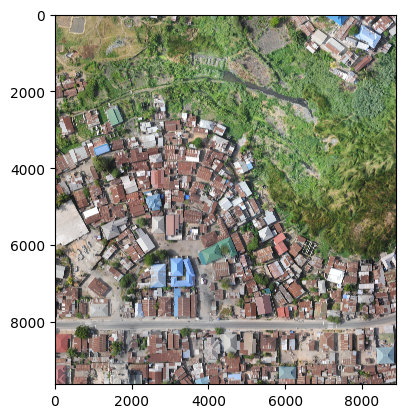

In [64]:
image_path = '01.tif'
image = plt.imread(image_path)
print(f"Image shape: {image.shape}")
plt.imshow(image[:,:,:3])
plt.show()

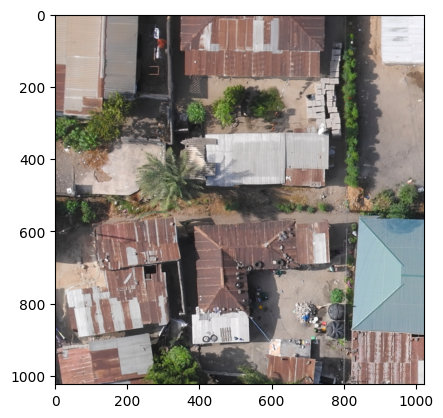

In [69]:
# visualise subset
plt.imshow(image[8606:,5000:6024,:3])
plt.show()

## Load model and predict

In [19]:
# initialize model and load weights
model = Unet(in_channels=3, classes=4, encoder_name='resnet34',
                     encoder_weights=None)
weights_path = "LarvalHabitats1/best_model"

model_weights = torch.load(weights_path, map_location='cpu')
model.load_state_dict(model_weights, strict=True)

<All keys matched successfully>

In [96]:
# predict
model.eval()
input = image[8606:,5000:6024,:3].transpose(2, 0, 1)[None, ...]
print(input.shape)
input = torch.from_numpy(input).float()/255
with torch.no_grad():
    output = model(input)

pred = torch.softmax(output, dim=1)
pred = torch.argmax(pred, dim=1)

(1, 3, 1024, 1024)


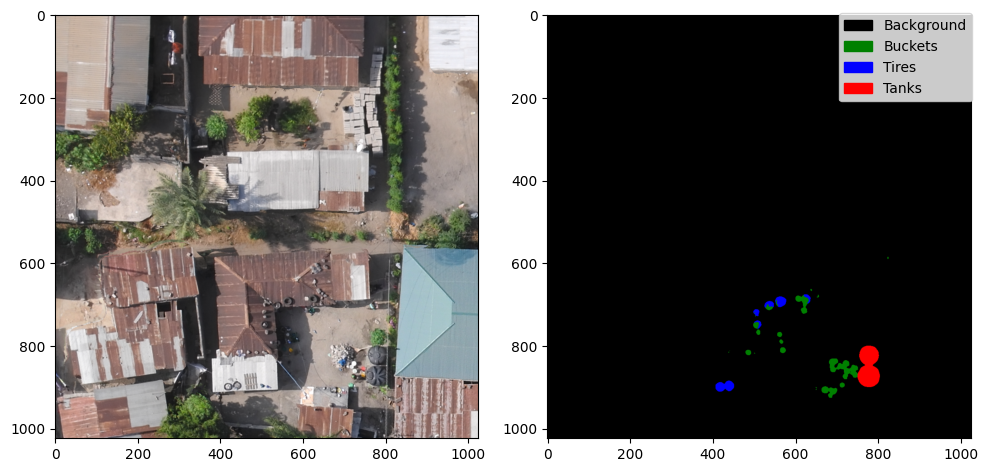

In [95]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# First image
axes[0].imshow(image[8606:,5000:6024,:3])

colors = ['Black', 'green', 'blue', 'red']
class_names = ['Background', 'Buckets', 'Tires', 'Tanks']

cmap = ListedColormap(colors)
norm = BoundaryNorm([0,1,2,3,4], cmap.N)

axes[1].imshow(pred.numpy()[0], cmap=cmap, norm=norm)

# Create legend
patches = [
    mpatches.Patch(color=colors[i], label=class_names[i])
    for i in range(len(class_names))
]

axes[1].legend(
    handles=patches,
    loc="center right",
    bbox_to_anchor=(1.02, 0.9)
)
plt.tight_layout()
plt.show()